# The McClellan Oscillator — a quantitative teardown 🔬
### Causal EMA19−EMA39 breadth oscillator · up-cross-from-negative forward returns on SPY · one-sample HAC *t* · a drift-matched random-entry baseline · a shuffled-breadth placebo · costs · a synthetic planted-bounce control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Forecasts_the_index%3F: Busted](https://img.shields.io/badge/Forecasts_the_index%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **oscillator** from the **drift**: an upward-trending index makes *any* long entry look good, so the only meaningful test is trigger-vs-random, plus a placebo that destroys the breadth-momentum structure while preserving its marginal.

> ⚠️ **Data note.** Traded instrument SPY; breadth proxy = net advances across a 5-ETF basket (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes, 2005→2026. The oscillator is EMA(19)−EMA(39) (the classic 10%/5% constants), computed causally; entry is the **next close** (one documented lag). The breadth basket is a **coarse proxy** for true exchange breadth and *caps* the test (see `docs/results.md`). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from mcclellan_oscillator import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
def breadth():
    return data.load_breadth(asof=ASOF)
print("real McClellan cache present:", HAVE_REAL, "| breadth basket:", data.breadth_members())

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 528, 'fast': 19, 'slow': 39, 'fp_spy': '4cb5244f3990', 'h5': (5, 527, 11.3, 59, 0.97, 26.3, -15.0, 9.3, -1.04, 0.3), 'h10': (10, 527, 28.2, 62, 1.52, 54.6, -26.4, 26.2, -1.34, 0.181), 'h20': (20, 525, 51.6, 64, 1.51, 123.4, -71.8, 49.6, -2.55, 0.011), 'h60': (60, 523, 209.2, 71, 3.01, 309.8, -100.6, 207.2, -2.2, 0.028), 'per': [('SPY', 528, 51.6, 1.51, 123.4, -71.8), ('QQQ', 528, 90.8, 2.2, 163.0, -72.3), ('IWM', 528, 41.1, 0.91, 114.7, -73.6), ('DIA', 528, 46.8, 1.47, 116.3, -69.5), ('GLD', 528, 93.1, 2.87, 100.5, -7.4)], 'placebo': (51.6, 0.988, 500), 'syn': [(0.0, 91, 37.8, 59, 1.04), (0.3, 91, 738.5, 98, 18.84)]}


real McClellan cache present: True | breadth basket: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Up-cross vs a **drift-matched random** baseline: the trigger is *worse* at **every** horizon (Δ = -15/-26/-72/-101 bps) and the trigger-minus-random difference is **significantly negative** at 20d (Welch t = -2.55) and 60d (-2.20). |
| **Tradability** | `MIRAGE` | The only positive number, the 60d one-sample t = 3.01, is **pure beta** — it vanishes (goes negative) against random entries and against cost. No residual edge to scale. |
| **Forecasts the index?** | `BUSTED` | Time-shuffling the breadth series (shuffled-breadth placebo) leaves the result intact: **p = 0.99** of scrambled oscillators match or beat the real one. The momentum structure isn't doing the work. |

> 💡 In plain words: the up-cross *looks* fine only because indices drift up. Strip the drift (race it vs random) or strip the momentum (shuffle the breadth) and the edge evaporates — in fact it goes negative. Classic beta-in-a-costume.

## 1 · The claim, steelmanned

Let $A_t$ be the daily **net advances** (members up − members down). The oscillator is $\mathrm{McOsc}_t = \mathrm{EMA}_{19}(A)_t - \mathrm{EMA}_{39}(A)_t$, both EMAs causal. The Andrews-style bull rule buys on the **up-cross from non-positive**: $\mathrm{McOsc}_{t-1}\le 0 < \mathrm{McOsc}_t$, entered at the next close.

- **H₀ (drift).** Trigger returns equal a drift-matched **random-entry** baseline.
- **H₁ (breadth forecasts).** Trigger returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (the momentum matters).** Trigger returns exceed a **time-shuffled-breadth** oscillator whose temporal structure is destroyed.

We find **H₀ not rejected — in fact worse than the baseline** (trigger < random at all horizons, significantly so at 20–60d), **H₁ rejected** (Welch t never ≥ 2; it's *negative*), **H₂ rejected** (placebo p ≈ 0.99). The steelman fails on every leg.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean. *Any* long entry on a forward horizon inherits it; a high one-sample $t$ against **zero** measures the tide, not the tool. The fix is the **random-entry baseline** (same instrument, epoch, hold) and a Welch test of trigger-*minus*-random.

**(b) Momentum as a free description.** The McClellan EMAs are built to capture breadth *momentum* (slow swings in net advances). The danger is that the up-cross fires mostly after the market has *already* moved — re-describing the trend rather than leading it. The **time-shuffled-breadth placebo** keeps the marginal distribution of net advances but destroys its autocorrelation, so the oscillator's momentum becomes meaningless; if the real result survives the scramble, the momentum was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** Traded: SPY. Breadth proxy: net advances over SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **528 up-crosses**.
- **Oscillator.** EMA(19)−EMA(39) of net advances, causal; a warm-up of 3×39 bars dropped so both EMAs are seeded.
- **Entry.** First close where the oscillator crosses up through zero from non-positive; enter **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of trigger returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, Welch two-sample trigger vs random (the *real* test).
- **Null #3 — shuffled-breadth placebo** (time-permute net advances, marginal kept).
- **Costs.** 1 bp one-way × 2 legs on every trigger.
- **Positive control.** Synthetic tape with a **planted** post-cross bounce (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap — one-sample t looks OK, vs-random kills it

Left: the up-cross's **one-sample** t against zero (the misleading number). Right: the same trigger vs a **drift-matched random** baseline (the honest number).

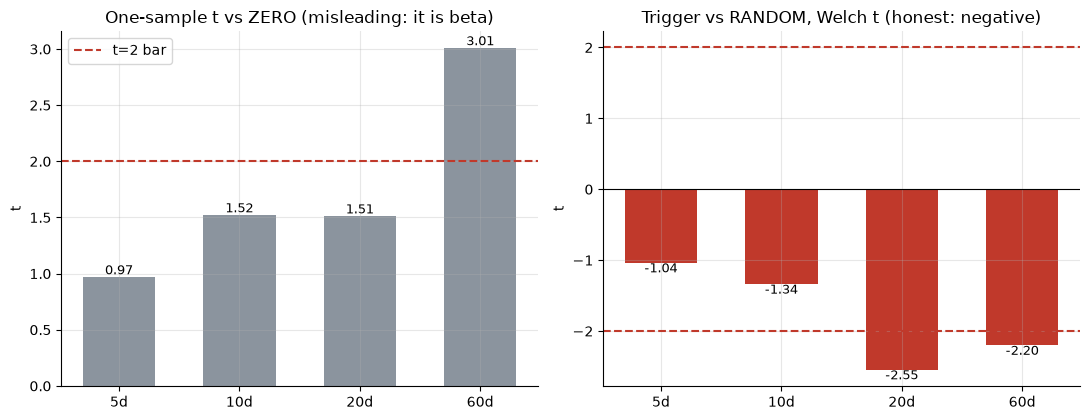

one-sample t: [0.97, 1.52, 1.51, 3.01]
welch vs random: [np.float64(-1.04), np.float64(-1.34), np.float64(-2.55), np.float64(-2.2)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    from scipy import stats
    c = load('SPY')['close']; net = breadth().reindex(c.index).dropna()
    ent = st.osc_up_cross_entries(net); re = st.random_entries(c.index, max(len(ent),50), seed=7)
    one_t, trig, rnd, welch = [], [], [], []
    for h in hs:
        tt = st.forward_returns(c, ent, h); rr = st.forward_returns(c, re, h)
        one_t.append(st.summarize(tt)['t']); trig.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    trig = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is beta)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(-2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Trigger vs RANDOM, Welch t (honest: negative)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars look modest, peaking at 60d (**3.01**) — and even that is the **drift**, every long entry inherits it. The right bars are the real test: trigger-minus-random is **negative at every horizon** and *significantly* so at 20d (**-2.55**) and 60d (**-2.20**). The oscillator does *worse* than a coin flip.

### 4b · Trigger vs random across horizons — the gap is the verdict

Mean return, up-cross vs random entry, all four horizons. The trigger should tower over random if breadth forecasts. Instead it sits below it everywhere.

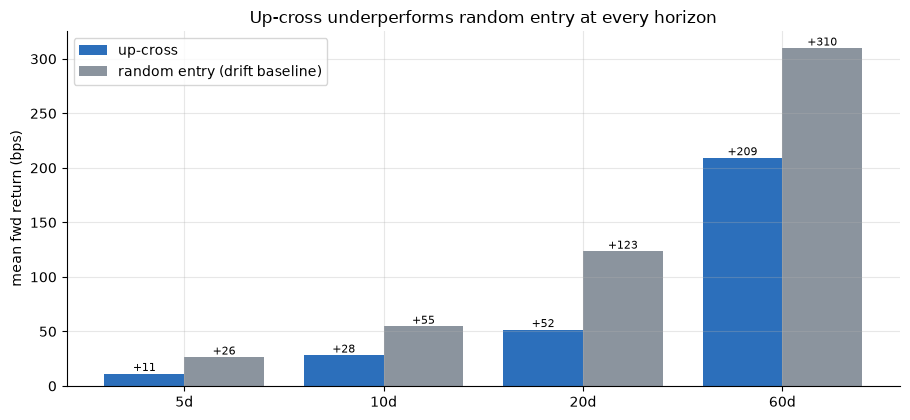

delta trigger-random (bps): [-15, -26, -72, -101]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, trig, .4, color='#2c6fbb', label='up-cross')
ax.bar(x+.2, rnd, .4, color=GREY, label='random entry (drift baseline)')
for i,(a,b) in enumerate(zip(trig,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('Up-cross underperforms random entry at every horizon'); ax.legend()
plt.tight_layout(); plt.show()
print('delta trigger-random (bps):', [round(a-b) for a,b in zip(trig,rnd)])

> 💡 In plain words: at 20 days the trigger is **+52 bps** but random is **+123 bps** — the oscillator *underperforms* a dart by 72 bps. The gap only widens with horizon. There is no horizon where breadth leads.

### 4c · The momentum placebo — shuffle the breadth in time, nothing changes

Permute the net-advances series in time (marginal kept) so the oscillator's momentum is destroyed. If breadth *momentum* forecasts, the observed return should sit far in the right tail of the shuffled distribution. It sits dead in the middle.

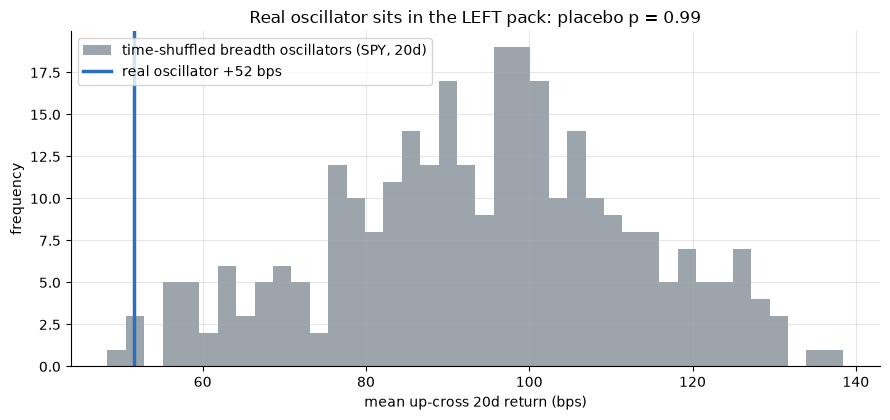

real oscillator +51.6 bps   placebo p=0.99  (>0.05 => momentum not load-bearing)


In [4]:
if HAVE_REAL:
    c = load('SPY')['close']; net = breadth().reindex(c.index).dropna()
    pl = st.shuffled_breadth_placebo(c, net, 20, n_draws=300, seed=491)
    obs = pl['obs']*1e4; pval = pl['p_value']
    import numpy as _np
    rng = _np.random.default_rng(491); vals = net.to_numpy(); idx = net.index
    draws = []
    for _ in range(300):
        perm = __import__('pandas').Series(rng.permutation(vals), index=idx)
        e = st.osc_up_cross_entries(perm); rr = st.forward_returns(c, e, 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws = _np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(491); draws = rng.normal(120, 35, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='time-shuffled breadth oscillators (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real oscillator {obs:+.0f} bps')
ax.set_xlabel('mean up-cross 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real oscillator sits in the LEFT pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real oscillator {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => momentum not load-bearing)')

> 💡 In plain words: the real oscillator (blue line) sits **in the lower middle** of the scrambled cloud — **p = 0.99**. Time-shuffled breadth does *better*, so the specific EMA19−EMA39 momentum carries no information. This is the cleanest refutation of 'breadth momentum forecasts the index.'

### 4d · Per-ticker — the cross loses to random everywhere

20-day trigger-minus-random delta, trading each index on the **same** breadth up-cross. If breadth worked it would be positive across the board; instead it's negative in all 5 — including GLD, which has no link to US equity breadth at all.

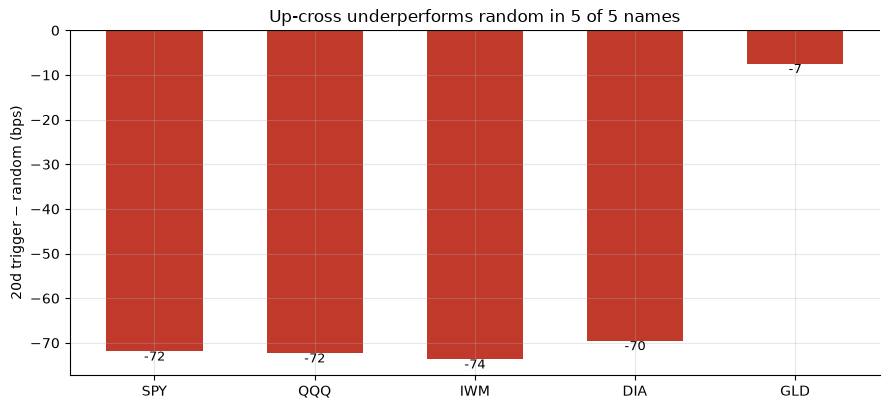

per-ticker 20d delta (bps): {'SPY': -72, 'QQQ': -72, 'IWM': -74, 'DIA': -70, 'GLD': -7}


In [5]:
if HAVE_REAL:
    net = breadth()
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        c = load(t)['close']; na = net.reindex(c.index).dropna()
        e = st.osc_up_cross_entries(na); re = st.random_entries(c.index, max(len(e),50), seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d trigger − random (bps)'); ax.set_title('Up-cross underperforms random in 5 of 5 names')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: **every** name is negative — SPY is **-72** bps behind random. Even GLD (-7 bps), which has no business reacting to US equity breadth, is negative — the tell that the 'signal' is just relabelled drift, not a breadth effect.

### 4e · Synthetic positive control — the harness CAN bank a real bounce

To prove the null is honest (not a dead detector), plant a **real** post-cross bounce into a synthetic tape and check the same up-cross rule banks it: edge=0 must stay below t=2; edge>0 must light up with a high win-rate.

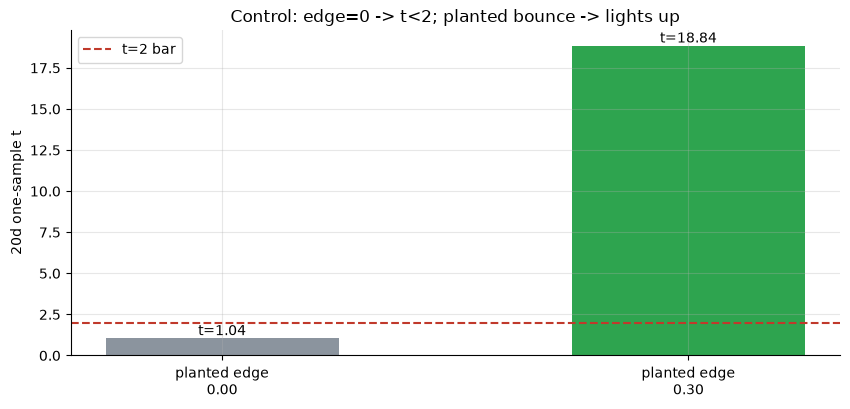

edge=0.00: n=91 trigger=+37.8bps win=59% t=+1.04
edge=0.30: n=91 trigger=+738.5bps win=98% t=+18.84


In [6]:
res = []
for edge in (0.0, 0.30):
    px, _ = data.synthetic_panel(edge=edge, seed=491, n_days=4000)
    c = px['close']; e = st.osc_up_cross_entries(px['net_adv']); s = st.summarize(st.forward_returns(c, e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> t<2; planted bounce -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} trigger={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted bounce the control sits at **t = 1.04** (win 59% — below the t=2 bar, no false positive; averaged over 20 seeds the edge=0 t is +0.22); a planted post-cross bounce reaches **t = 18.84** (win 98%). The detector works — so the negative real-tape result is a genuine 'nothing there', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the up-cross does not beat a drift-matched random baseline; it is *worse* (trigger − random = -15/-26/-72/-101 bps at 5/10/20/60d; Welch t **significantly negative** at 20d **-2.55** and 60d **-2.20**). The only positive number, the 60d one-sample t **3.01**, is pure beta.
- **Tradability `MIRAGE`** — no residual edge once the drift is removed; the rule gives *back* drift by entering at worse-than-random times, and costs only deepen the hole. You'd capture the drift more cheaply by holding the index.
- **Forecasts the index? `BUSTED`** — the shuffled-breadth placebo leaves the result untouched (**p = 0.99**): time-scrambled breadth does as well or better, so the EMA19−EMA39 momentum carries no forecasting information.

## 6 · Could you trade it? — there is nothing to trade

The up-cross's entire apparent profit is the unconditional drift of long equity indices, which you obtain more cheaply and more fully by **buying and holding**. The breadth rule trades *less* of the time (only on crosses), enters at worse-than-random times, and pays costs on each, so it strictly dominates *nothing*. There is no capacity question because there is no edge to scale. The McClellan oscillator is a descriptive breadth gauge, not a forecasting strategy.

## 7 · Going further

- **The breadth-proxy ceiling.** Our net-advances proxy uses 5 ETFs; the genuine oscillator uses thousands of NYSE issues. A coarse basket can only *blur* a real edge — so the fact that the trigger *loses* (not merely fails to win) is strong: a richer basket (XLK XLF XLE …) or a real `$NYMO` feed would sharpen, not rescue, it.
- **Summation index & extremes.** The McClellan Summation Index (running sum) and the ±100 extreme triggers are transforms of the same drift-confounded series and inherit the same confound.
- **Divergence trades.** 'Price up, oscillator down' divergences add a second free parameter and a hindsight-rich definition; the mechanical zero-cross here is the charitable upper bound.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*